# <span style="color:#233d4d"><b>ACTIVITY 2 </b> <i>(Logistic Regression with a Binary Outcome)</i></span>

### <span style="color:#fe7f2d">Belarmino, Llona, Ojeñar, Relayo, Sanoy, & Siao</span>

## <span style="color:#a1c181"><u>1. Importing Libraries</u></span>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

## <span style="color:#fcca46"><u>2. Importing Data Set</u></span>

In [ ]:
data = pd.read_csv("student_pass.csv")
data

,Student,Hours_Studied,Pass
0,1,6.39,1
1,2,0.25,0
2,3,2.23,1
3,4,6.77,1
4,5,8.92,1
5,6,0.87,0
6,7,0.30,0
7,8,5.05,1
8,9,0.27,0
9,10,6.50,1


## <span style="color:#a1c181"><u>3. Visualizing Raw Data </u></span>

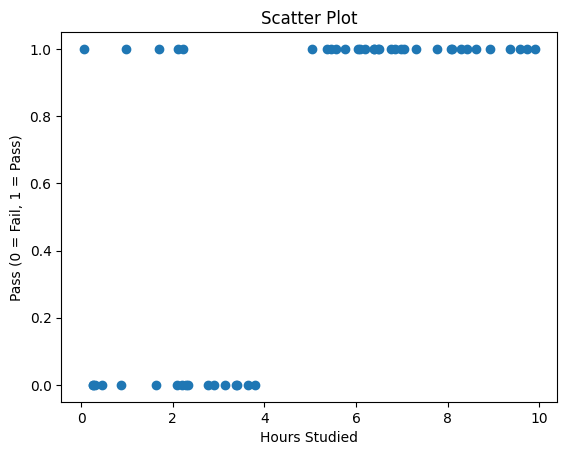

In [ ]:
plt.scatter(data['Hours_Studied'], data['Pass'])
plt.xlabel('Hours Studied')
plt.ylabel('Pass (0 = Fail, 1 = Pass)')
plt.title('Scatter Plot')
plt.show()

### <span style="color:#619b8a"><u>4. Splitting Into Training and Testing Datasets</u></span>

In [ ]:
X = data[['Hours_Studied']]
y = data['Pass']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## <span style="color:#233d4d"><u>5. Implementing Logistic Regression</u></span>

In [ ]:
model = LogisticRegression()
model.fit (X_train, y_train)

LogisticRegression()

## <span style="color:#fe7f2d"><u>6. Predicting With Test Data</u></span>

In [ ]:
predictions = model.predict(X_test)
for hours, status in zip(X_test['Hours_Studied'].values, predictions):
    status = "Pass" if status == 1 else "Fail"
    print(f"If student studied for {hours} hours, the predicted outcome is: {status}")

If student studied for 0.06 hours, the predicted outcome is: Fail
If student studied for 1.71 hours, the predicted outcome is: Fail
If student studied for 0.46 hours, the predicted outcome is: Fail
If student studied for 8.43 hours, the predicted outcome is: Pass
If student studied for 3.37 hours, the predicted outcome is: Fail
If student studied for 3.15 hours, the predicted outcome is: Fail
If student studied for 6.19 hours, the predicted outcome is: Pass
If student studied for 8.29 hours, the predicted outcome is: Pass
If student studied for 2.33 hours, the predicted outcome is: Fail
If student studied for 6.04 hours, the predicted outcome is: Pass


## <span style="color:#fcca46"><u>7. Evaluating the Model</u></span>

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, log_loss

predictions = model.predict(X_test)

predicted_probabilities = model.predict_proba(X_test)

accuracy = accuracy_score(y_test, predictions)
logloss = log_loss(y_test, predicted_probabilities, labels=[0, 1])

print("Accuracy:", accuracy)
print("Classification Report:")
print(classification_report(y_test, predictions, target_names=["Fail", "Pass"], zero_division=0))
print("Log Loss:", logloss)

Accuracy: 0.8
Classification Report:
              precision    recall  f1-score   support

        Fail       0.67      1.00      0.80         4
        Pass       1.00      0.67      0.80         6

    accuracy                           0.80        10
   macro avg       0.83      0.83      0.80        10
weighted avg       0.87      0.80      0.80        10

Log Loss: 0.6728987057428094


## <span style="color:#a1c181"><u>8. Predicting Specific Study Hours</u></span>

In [ ]:
specific_hours = pd.DataFrame({'Hours_Studied': [6.7, 9.11, 24.0, 0.5, 1.0, 2.0, 3.0, 4.0, 3.5, 3.2, 3.36, 3.37, 3.38, 3.39]})

predicted_status = model.predict(specific_hours)
predicted_probs = model.predict_proba(specific_hours)[:, 1]

for hr, status, prob in zip(specific_hours['Hours_Studied'], predicted_status, predicted_probs):
    result = "Pass" if status == 1 else "Fail"
    print(f"Hours Studied: {hr} -> Predicted: {result} (Probability of Passing: {prob:.4f})")

Hours Studied: 6.7 -> Predicted: Pass (Probability of Passing: 0.9574)
Hours Studied: 9.11 -> Predicted: Pass (Probability of Passing: 0.9954)
Hours Studied: 24.0 -> Predicted: Pass (Probability of Passing: 1.0000)
Hours Studied: 0.5 -> Predicted: Fail (Probability of Passing: 0.0636)
Hours Studied: 1.0 -> Predicted: Fail (Probability of Passing: 0.0978)
Hours Studied: 2.0 -> Predicted: Fail (Probability of Passing: 0.2165)
Hours Studied: 3.0 -> Predicted: Fail (Probability of Passing: 0.4134)
Hours Studied: 4.0 -> Predicted: Pass (Probability of Passing: 0.6424)
Hours Studied: 3.5 -> Predicted: Pass (Probability of Passing: 0.5294)
Hours Studied: 3.2 -> Predicted: Fail (Probability of Passing: 0.4594)
Hours Studied: 3.36 -> Predicted: Fail (Probability of Passing: 0.4967)
Hours Studied: 3.37 -> Predicted: Fail (Probability of Passing: 0.4990)
Hours Studied: 3.38 -> Predicted: Pass (Probability of Passing: 0.5014)
Hours Studied: 3.39 -> Predicted: Pass (Probability of Passing: 0.5037)


## <span style="color:#619b8a"><u>9. Plotting a Sigmoid-shaped Logistic Regression Curve</u></span>

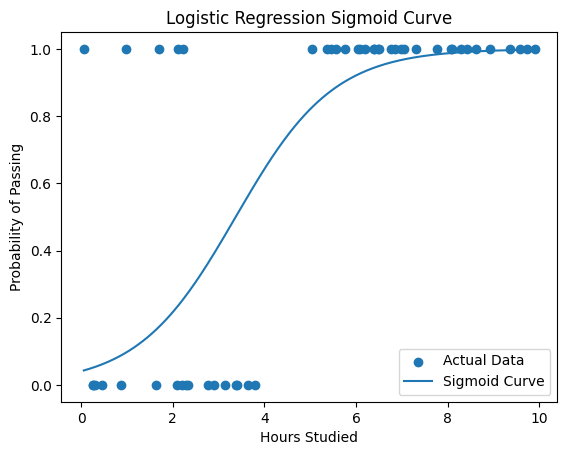

In [ ]:
x_values = pd.DataFrame({
    'Hours_Studied': np.linspace(data['Hours_Studied'].min(), data['Hours_Studied'].max(), 300)
})

y_prob = model.predict_proba(x_values)[:, 1]

plt.scatter(data['Hours_Studied'], data['Pass'], label='Actual Data')
plt.plot(x_values['Hours_Studied'], y_prob, label='Sigmoid Curve')

plt.xlabel('Hours Studied')
plt.ylabel('Probability of Passing')
plt.title('Logistic Regression Sigmoid Curve')
plt.legend()
plt.show()

## <span style="color:#619b8a"><u>Interpretations</u></span>

1. *Importing Libraries*

* `pandas` is used to handle and organize the dataset.
* `numpy` is used for numerical operations.
* `matplotlib` is used to visualize the data.
* `train_test_split` helps divide the dataset into training and testing sets.
* `LogisticRegression` is the main algorithm used to predict whether a student passes or fails.


2. *Importing Dataset*

The dataset `student_pass.csv` is loaded into the notebook. It contains two variables:

**Hours_Studied** (input feature)

**Pass** (output: 1 = pass, 0 = fail)

This step ensures that the data is ready for analysis and modeling.


3. *Visualizing Raw Data*

A scatter plot is created to show the relationship between study hours and passing status.


*   Points with value **0** represent students who failed.
*   Points with value **1** represent students who passed.

*   We can observe that as study hours increase, the likelihood of passing also increases.

This confirms that logistic regression is appropriate since the outcome is binary (pass/fail).

4. *Splitting into Training and Testing Data*

The dataset is divided into:


*  Training set (80%) → used to train the model
*  Testing set (20%) → used to evaluate performance

This step prevents overfitting and ensures the model can generalize to new data.

5. *Implementing Logistic Regression*

A logistic regression model is created and trained using the training data.


*   The model learns the relationship between study hours and probability of passing.
*   It fits a sigmoid (S-shaped) curve to represent this relationship.

6. *Predicting with Test Data*

The model predicts whether students pass or fail based on unseen test data.


*   For each number of study hours, the model outputs a classification (Pass/Fail).
*   This demonstrates how the model can be used for real-world predictions.


7. *Evaluating the Model*

The performance of the logistic regression model is evaluated using Accuracy, Classification Report, and Log Loss, which are more appropriate metrics for classification tasks.

*   The model achieved an accuracy of 0.8000 (80%), which means that 8 out of 10 predictions were classified correctly.
*   For students who failed, the model has a precision of 0.67 and a recall of 1.00, meaning it successfully identified all actual failing students.
* For students who passed, the model has a precision of 1.00 and a recall of 0.67, which means all predicted passing students were correct, but some actual passing students were predicted as fail.
* The F1-score of 0.80 for both classes shows a balanced performance between precision and recall.
* The Log Loss value of 0.6729 indicates the quality of probability predictions. Since lower log loss is better, this suggests that the model provides reasonably good probability estimates.

8. *Predicting Specific Study Hours*

The model is used to predict whether a student will pass or fail based on specific numbers of study hours. It also provides the probability of passing for each input value.

* Students who studied for 6.7 hours and 9.11 hours were predicted to Pass, with high probabilities of 0.9574 and 0.9954, showing that more study hours greatly increase the chance of passing.
* Students who studied for only 0.5, 1.0, and 2.0 hours were predicted to Fail, with low passing probabilities of 0.0636, 0.0978, and 0.2165, indicating that very low study time reduces the likelihood of success.
* At 3.0 hours, the probability of passing is 0.4134, which is still predicted as Fail.
* At 4.0 hours, the probability increases to 0.6424, and the prediction becomes Pass, showing the transition point where the model begins predicting a passing result.
* Based on the tested values, the model shows that the minimum number of study hours needed for a student to be predicted as Pass is 3.3800 hours.
* At 3.37 hours, the student is still predicted to Fail, while at 3.38 hours, the prediction changes to Pass.

This means that a student should study for at least 3.3800 hours to have a passing prediction according to the logistic regression model.

9. *Plotting the Sigmoid Curve*

A sigmoid curve is plotted to visualize the logistic regression model and show how the probability of passing changes as study hours increase.

* The scatter plot represents the actual dataset, where students are classified as either Fail (0) or Pass (1) based on their study hours.
* The smooth S-shaped line represents the sigmoid curve generated by the logistic regression model.
* At lower study hours, the probability of passing is close to 0, meaning students are more likely to fail.
* As study hours increase, the probability gradually rises until it approaches 1, meaning students become more likely to pass.
* The middle part of the curve shows the decision boundary where the prediction changes from fail to pass, which happens around 3.38 hours of study time.

This visualization clearly shows that increasing study hours improves the probability of passing, making logistic regression effective for predicting student performance.